<a href="https://colab.research.google.com/github/nuriarichergusano/Physics-Internship-Projects/blob/main/Proyecto_Ski.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ski Resort Route Optimization Project with GIS and LIDAR**
### In this first test I will focus in the ski station of Grandvalira.





1.   **Databases.**
### We have several types of databases. One is the data of the slopes and lifts; another is that of discretized altitude along each slope; another is the real-time data of congestion/waiting at each lift; another is the meteorological factor (depending on the type of snow we will add warnings in which area (towards east/west/south/north) there will be one type of snow or another that we can add as a parameter to add in the dropdown of filters) that we can also add avalanche/danger warnings (ultimate responsibility of the skier).




2. **Ski resort route optimization algorithm.**

###Later I can improve the function to allow partial searches or handle ambiguities (for example, if there are two slopes with similar names). Also, the choice of which node to use (start or end) may depend on the logic of your application (for example, you may want to allow selecting the start and end node of each slope differently). Add also the popularity factor of routes or slopes made by other skiers. Later you should include the waiting time in the lifts and adjust the speed of each segment according to the skier's level and apply filters (for example, limiting the use of very difficult slopes).

Python 3.11.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 51.1 MB/s eta 0:00:00
Slope name: La Mine
Slope type: downhill
  - Lat: 42.5411861, Lon: 1.7686064
  - Lat: 42.5411212, Lon: 1.7684874
  - Lat: 42.5411180, Lon: 1.7684724
  - Lat: 42.5411148, Lon: 1.7684538
  - Lat: 42.5411221, Lon: 1.7684313
  - Lat: 42.5411420, Lon: 1.7684153
  - Lat: 42.5411775, Lon: 1.7684194
  - Lat: 42.5417428, Lon: 1.7686076
  - Lat: 42.5422468, Lon: 1.7687974
  - Lat: 42.5427295, Lon: 1.7691989
  - Lat: 42.5429159, Lon: 1.7698096
  - Lat: 42.5428808, Lon: 1.7702673
  - Lat: 42.5427062, Lon: 1.7707295
  - Lat: 42.5425782, Lon: 1.7709186
  - Lat: 42.5426259, Lon: 1.7711418
  - Lat: 42.5431192, Lon: 1.7712826
  - Lat: 42.5444414, Lon: 1.7716605
  - Lat: 42.5448622, Lon: 1.7721300
  - Lat: 42.5455636, Lon: 1.7726135
  - Lat: 42.5460982, Lon: 1.7736349
  - Lat: 42.5466759, Lon: 1.7744687
  - Lat: 42.5469085, Lon: 1.7754949
  - Lat: 42.5467959, Lon: 1.7760869
  - Lat: 42.5467777, Lon: 1.7771131
 

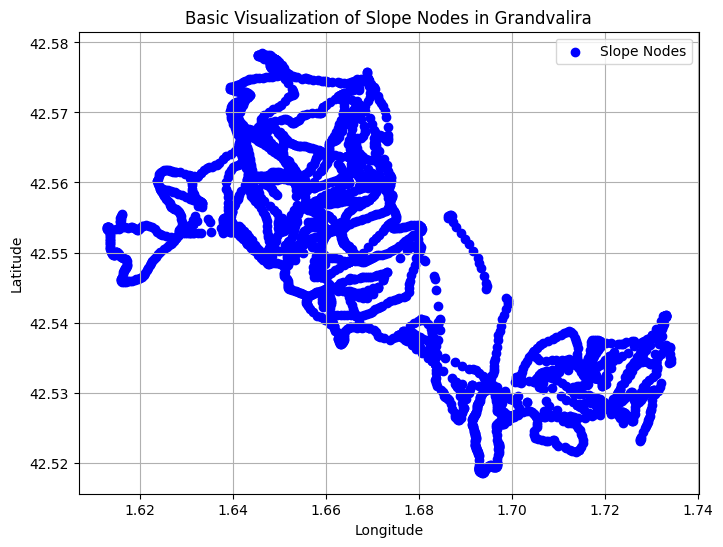

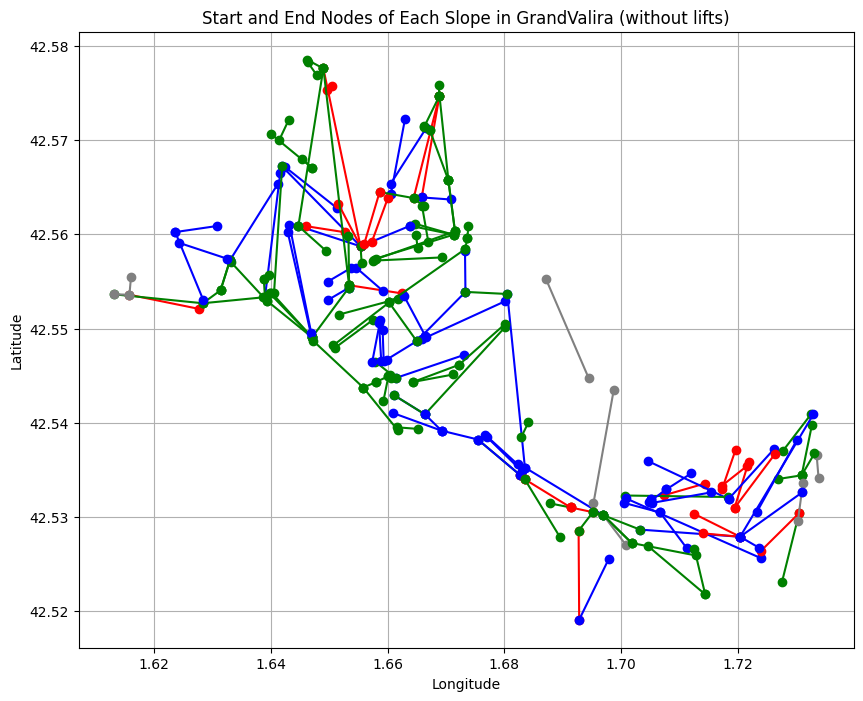

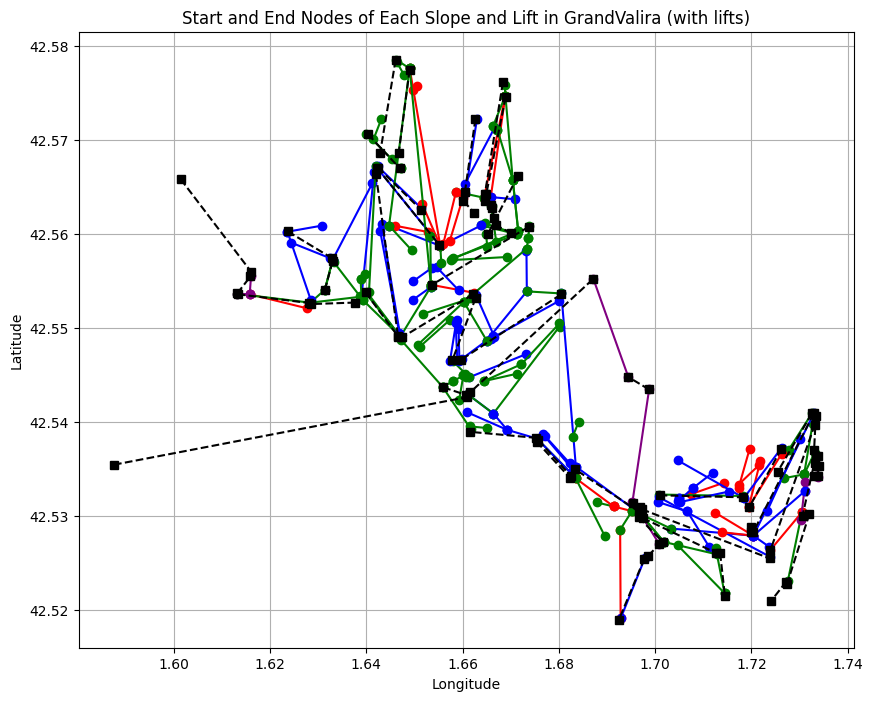

Number of free nodes: 246
Number of possible combinations between free nodes: 30135
--------------------------------------------------
Number of slopes extracted: 163
Number of lifts extracted: 53
--------------------------------------------------
Maximum distance between free nodes: 11.99 km
Number of combinations (end-to-end routes) with the maximum distance: 1
Difficulty levels found on the slopes:
advanced
easy
intermediate
novice
Slope: Forn
Slope: Forest Pas
Slope: Valira 1
Slope: Valira 2
Slope: Forn
Slope: Kid's Forest
Slope: Pista Escola
Slope: Unnamed
Download completed. File saved as 'andorra_srtm_gl1.tif'.
Slope ID: 48928224
  Node 1: Lat: 42.5609124, Lon: 1.6638859, Elev: 2315
  Node 2: Lat: 42.5611362, Lon: 1.6646426, Elev: 2295
  Node 3: Lat: 42.5614178, Lon: 1.6652499, Elev: 2284
  Node 4: Lat: 42.5616231, Lon: 1.6653877, Elev: 2281
  Node 5: Lat: 42.5619153, Lon: 1.6654028, Elev: 2273
  Node 6: Lat: 42.5622745, Lon: 1.6653577, Elev: 2266
  Node 7: Lat: 42.5626162, Lon:

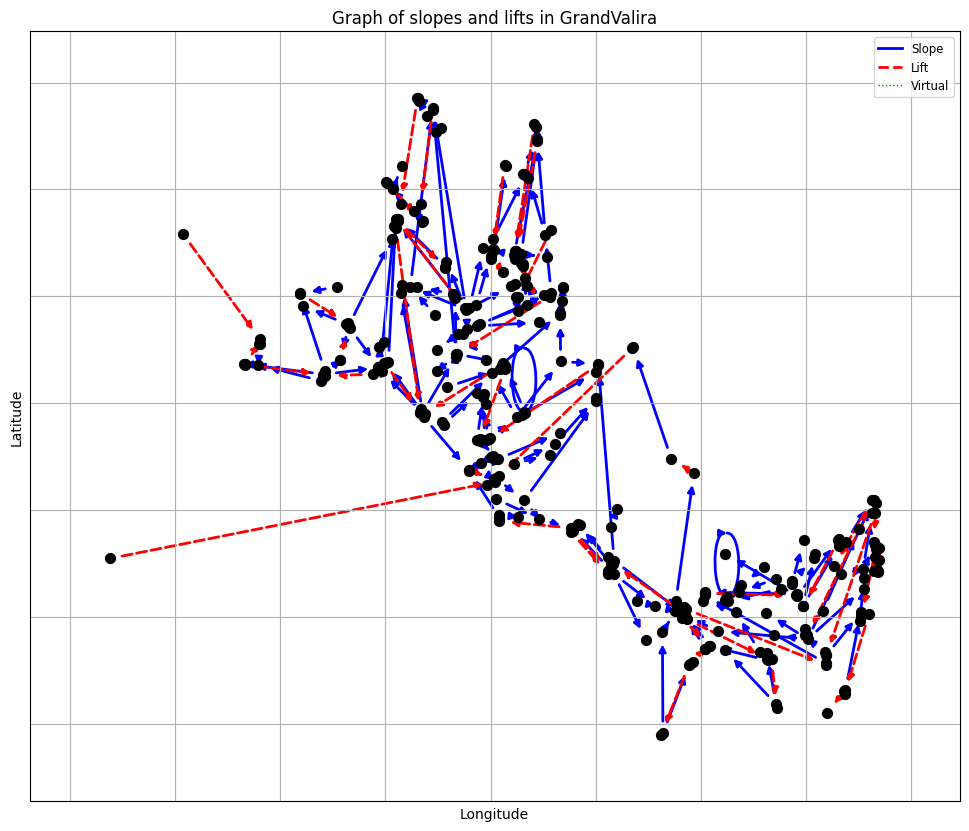

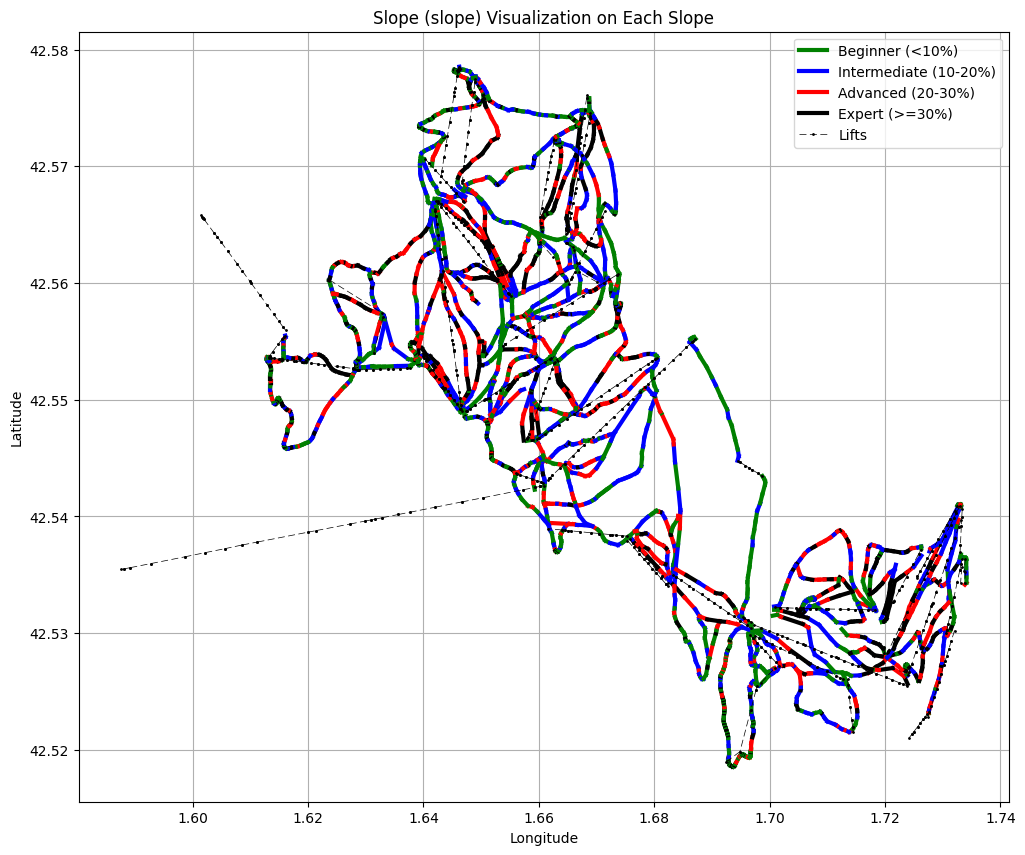

KeyboardInterrupt: Interrupted by user

In [1]:
# **Ski Resort Route Optimization Project**
# ### In this first test I will focus only on the Pas de la Casa Sector and maybe some nearby or in Grandvalira. I have to test an even simpler example like Valdesqui, for example.

# ##1. Databases.
# ### We have several types of databases. One is the data of the slopes and lifts; another is that of discretized altitude along each slope; another is the real-time data of congestion/waiting at each lift; another is the meteorological factor (depending on the type of snow we will add warnings in which area (towards east/west/south/north) there will be one type of snow or another that we can add as a parameter to add in the dropdown of filters) that we can also add avalanche/danger warnings (ultimate responsibility of the skier).


# Slope/lift data: Open Street Maps (OSM)
# I start by installing the necessary packages.
!python --version #I check the version of python that is installed.
!pip install overpy #for queries to the Overpass API
!pip install geopandas #geospatial data
!pip install rasterio #for Digital Elevation Model (DEM), altitudes



# As I am making a basic model, I reduce the area to Pas de la Casa and its surroundings,
# defining a bounding box (bounding rectangle) with value (42.53,1.76,42.55,1.80).
# These are not the correct coordinates, but it's a good start.

# Way: line that joins nodes to form lines or polygons.

import overpy

# Initialize the Overpass API
api = overpy.Overpass()

# Define an approximate bounding box for Pas de la Casa and its surroundings.
# (lat_min, lon_min, lat_max, lon_max) - adjust these values according to your area of interest.
query = """
way
  ["piste:type"]
  (42.53,1.76,42.55,1.80);
(._;>;);
out;
"""

# Execute the query
result = api.query(query)

# Process the results and display information
for way in result.ways:
    name = way.tags.get("name", "Unknown")
    piste_type = way.tags.get("piste:type", "N/A")

    print(f"Slope name: {name}")
    print(f"Slope type: {piste_type}")

    for node in way.nodes:
        print(f"  - Lat: {node.lat}, Lon: {node.lon}")
    print("-------------------------------------------------")


# If instead of defining a bounding box I use the Grandvalira relation of OSM:
import overpy
import matplotlib.pyplot as plt

# Initialize the Overpass API
api = overpy.Overpass()

# Define the ID of the GrandValira relation
relation_id = 3445954

# Query to get the relation, its members and the geometry
query = f"""
[out:json][timeout:25];
relation({relation_id});
out geom;
>;
out geom;
"""

# Execute the query
result = api.query(query)

# Lists to store the ways (slopes and lifts)
slopes = []
lifts = []

# Filter the ways according to their tags:
for way in result.ways:
    if "piste:type" in way.tags:
        slopes.append(way)
    elif "aerialway" in way.tags:
        lifts.append(way)

print("Number of slopes extracted:", len(slopes))
print("Number of lifts extracted:", len(lifts))
print("--------------------------------------------------")

# Function to extract nodes (lat, lon, ele) from a way.
def extract_nodes_with_altitude(way):
    nodes = []
    if hasattr(way, "nodes") and way.nodes:
        for node in way.nodes:
            ele = None
            if hasattr(node, "tags") and node.tags:
                ele = node.tags.get("ele")
            nodes.append((node.lat, node.lon, ele))
    return nodes

# Process each slope: print the data of each node (including the altitude, if it exists)
for slope in slopes:
    nodes = extract_nodes_with_altitude(slope)
    if not nodes:
        continue
    print("Slope ID:", slope.id)
    print("Tags:", slope.tags)
    print("Slope Nodes (Lat, Lon, Ele):")
    for idx, (lat, lon, ele) in enumerate(nodes):
        print(f"  Node {idx+1}: Lat: {lat}, Lon: {lon}, Ele: {ele if ele is not None else 'NA'}")
    print("--------------------------------------------------")

# Process each lift: print the data of each node (including the altitude, if it exists)
for lift in lifts:
    nodes = extract_nodes_with_altitude(lift)
    if not nodes:
        continue
    print("Lift ID:", lift.id)
    print("Tags:", lift.tags)
    print("Lift Nodes (Lat, Lon, Ele):")
    for idx, (lat, lon, ele) in enumerate(nodes):
        print(f"  Node {idx+1}: Lat: {lat}, Lon: {lon}, Ele: {ele if ele is not None else 'NA'}")
    print("--------------------------------------------------")



# Simple visualization of Grandvalira: plot the points (lat, lon) of each slope.
# Including intermediate nodes.
points = []
for slope in slopes:
    # Extract the nodes for visualization (without altitude)
    for node in slope.nodes:
        points.append((node.lat, node.lon))

if points:
    lats, lons = zip(*points)
    plt.figure(figsize=(8, 6))
    plt.scatter(lons, lats, c="blue", label="Slope Nodes", marker="o")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Basic Visualization of Slope Nodes in Grandvalira")
    plt.legend()
    plt.grid(True)
    plt.show()
# Visualization: connect all nodes of each slope
# Function to extract nodes (lat, lon) from a way.
def extract_nodes(way):
    nodes = []
    if hasattr(way, "nodes") and way.nodes:
        for node in way.nodes:
            nodes.append((node.lat, node.lon))
    return nodes

# Color map based on the "piste:difficulty" tag
color_map = {
    "easy": "green",
    "intermediate": "blue",
    "advanced": "red",
    "expert": "purple"
}

# Visualization: connect only the start and end node of each slope
plt.figure(figsize=(10, 8))
for slope in slopes:
    nodes = extract_nodes(slope)
    if len(nodes) < 2:
        continue  # At least start and end node are required
    # Start and end node
    start = nodes[0]
    end = nodes[-1]

    # Determine the color based on the "piste:difficulty" tag
    difficulty = slope.tags.get("piste:difficulty", "unknown")
    color = color_map.get(difficulty.lower(), "gray")

    # Plot the line connecting the start and end node
    lons = [start[1], end[1]]
    lats = [start[0], end[0]]
    plt.plot(lons, lats, marker="o", color=color, label=f"Slope {slope.id} ({difficulty})")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Start and End Nodes of Each Slope in GrandValira (without lifts)")
#plt.legend(fontsize="small", loc="best")
plt.grid(True)
plt.show()

# Visualization of slopes (ways), now with lifts (lifts/aerial) added.

import overpy
import matplotlib.pyplot as plt

# Function to extract nodes (lat, lon) from a way.
def extract_nodes(way):
    nodes = []
    if hasattr(way, "nodes") and way.nodes:
        for node in way.nodes:
            nodes.append((node.lat, node.lon))
    return nodes

# Color map based on the "piste:difficulty" tag for the slopes
color_map = {
    "easy": "green",
    "intermediate": "blue",
    "advanced": "red",
    "novice": "purple"
}
#novice: beginner, the easiest of all.

# Visualization: connect only the start and end node of each slope and lift
plt.figure(figsize=(10, 8))

# Visualize the slopes
for slope in slopes:
    nodes = extract_nodes(slope)
    if len(nodes) < 2:
        continue  # At least start and end node are required
    # Start and end node
    start = nodes[0]
    end = nodes[-1]

    # Determine the color based on the "piste:difficulty" tag
    difficulty = slope.tags.get("piste:difficulty", "unknown")
    color = color_map.get(difficulty.lower(), "gray")

    # Plot the line connecting the start and end node
    lons = [start[1], end[1]]
    lats = [start[0], end[0]]
    plt.plot(lons, lats, marker="o", color=color, linestyle="-",
             label=f"Slope {slope.id} ({difficulty})")

# Visualize the lifts (with square marker and dashed line)
lift_color = "black"
for lift in lifts:
    nodes = extract_nodes(lift)
    if len(nodes) < 2:
        continue
    start = nodes[0]
    end = nodes[-1]
    lons = [start[1], end[1]]
    lats = [start[0], end[0]]
    plt.plot(lons, lats, marker="s", color=lift_color, linestyle="--",
             label=f"Lift {lift.id}")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Start and End Nodes of Each Slope and Lift in GrandValira (with lifts)")
#plt.legend(fontsize="small", loc="best")
plt.grid(True)
plt.show()

# Additional calculations: check isolated nodes and calculate the number of combinations.
from math import radians, sin, cos, sqrt, asin

# Function to extract endpoints (start and end node) of a way,
# returning a tuple (lat, lon) rounded to 6 decimal places
def extract_endpoints(way):
    nodes = extract_nodes(way)
    if len(nodes) < 2:
        return []
    start = nodes[0]
    end = nodes[-1]
    # Round to avoid precision problems
    start_rounded = (round(start[0], 6), round(start[1], 6))
    end_rounded = (round(end[0], 6), round(end[1], 6))
    return [start_rounded, end_rounded]

# Create a dictionary to count the appearance of each endpoint
endpoint_dict = {}

# Join slopes and lifts into a single list of elements
elements = slopes + lifts

for elem in elements:
    endpoints = extract_endpoints(elem)
    for ep in endpoints:
        endpoint_dict[ep] = endpoint_dict.get(ep, 0) + 1

# "Free nodes" are those that appear only once
free_nodes = [ep for ep, count in endpoint_dict.items() if count == 1]

num_free_nodes = len(free_nodes)
print("Number of free nodes:", num_free_nodes)

# Number of possible combinations between free nodes (n choose 2)
if num_free_nodes >= 2:
    combinations = num_free_nodes * (num_free_nodes - 1) // 2
else:
    combinations = 0

print("Number of possible combinations between free nodes:", combinations)
print("--------------------------------------------------")
print("Number of slopes extracted:", len(slopes))
print("Number of lifts extracted:", len(lifts))

# --- Block to calculate combinations of end-to-end routes (the longest) ---
print("--------------------------------------------------")
# Function to calculate the haversine distance between two points
def haversine(lat1, lon1, lat2, lon2):
    r = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return r * c

max_distance = 0
max_pairs = []

# Compare each pair of free nodes
for i in range(num_free_nodes):
    for j in range(i+1, num_free_nodes):
        lat1, lon1 = free_nodes[i]
        lat2, lon2 = free_nodes[j]
        d = haversine(lat1, lon1, lat2, lon2)
        if d > max_distance:
            max_distance = d
            max_pairs = [(free_nodes[i], free_nodes[j])]
        elif abs(d - max_distance) < 1e-6:  # Tolerance to consider equal distances
            max_pairs.append((free_nodes[i], free_nodes[j]))

print("Maximum distance between free nodes: {:.2f} km".format(max_distance))
print("Number of combinations (end-to-end routes) with the maximum distance:", len(max_pairs))
# I will try to do the same but extracting the database from a downloaded Torrent
# file. The other method is surely more useful because we connect
# directly to the API.

# As there is a discrepancy between the official Grandvalira map and the levels of
# difficulty given by OpenStreetMaps (OSM), these commands allow us to see where the error is.

# Create a set to store the difficulty levels found
difficulty_levels = set()

# Go through each slope and extract the difficulty tag
for slope in slopes:
    difficulty = slope.tags.get("piste:difficulty", "unknown")
    difficulty_levels.add(difficulty.lower())

# Print the difficulty levels found
print("Difficulty levels found on the slopes:")
for level in sorted(difficulty_levels):
    print(level)

# Extract and print the name of the slopes with difficulty "novice"
for slope in slopes:
    difficulty = slope.tags.get("piste:difficulty", "").lower()
    if difficulty == "novice":
        name = slope.tags.get("name", "Unnamed")
        print("Slope:", name)


# **MISSING TO THINK HOW I ADD THE DISCRETIZED ALTITUDE IN EACH SLOPE.**

# **Also do the same but with the torrent metadata instead of accessing the API through overpy**

# **The next step besides checking that the visualization is correct is to see how many nodes there are without connecting and also add the entire optimization algorithm part**

# Regarding adding elevation, altitude or slope to my model:

# OSM does not store the slope for each road segment. It may appear on some slopes
# an indicative tag (e.g. incline=10%), but it is not the norm.
# Most viewers or services that show elevation profiles perform
# a calculation of their own from the geometry (lat/lon) and data from a model of
# elevation (SRTM, LIDAR, etc.) - DEM.

# First, to obtain the elevation data I will use an OpenSource GeoTIFF,
# which I can download from python, using a bounding box, in the following way:

import requests

url = "https://portal.opentopography.org/API/globaldem"
params = {
    "demtype": "SRTMGL1",
    "south": 42.42,
    "north": 42.66,
    "west": 1.40,
    "east": 1.80,
    "outputFormat": "GTiff",
    "API_Key": "demoapikeyot2022"
}

# GET request to the API
response = requests.get(url, params=params, stream=True)

# Save the response to a .tif file
with open("andorra_srtm_gl1.tif", "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download completed. File saved as 'andorra_srtm_gl1.tif'.")

#-------------------------------------------------------------------------------

import rasterio

# Path to the downloaded DEM (adjust the path according to where the file is located)
dem_path = "andorra_srtm_gl1.tif"

# Open the DEM
dem = rasterio.open(dem_path)

# Function that, given a coordinate (lat, lon), returns the elevation extracted from the DEM.
def get_elevation_for_node(lat, lon, dem):
    try:
        # rasterio.index expects (lon, lat)
        row, col = dem.index(lon, lat)
        elevation = dem.read(1)[row, col]
        return elevation
    except Exception as e:
        print(f"Error for the coordinate ({lat}, {lon}): {e}")
        return None

# Function to extract the nodes of a slope enriched with elevation.
def extract_nodes_with_elevation(way, dem):
    nodes_elev = []
    if hasattr(way, "nodes") and way.nodes:
        for node in way.nodes:
            elev = get_elevation_for_node(node.lat, node.lon, dem)
            nodes_elev.append((node.lat, node.lon, elev))
    return nodes_elev

# Example: Print the nodes (with elevation) for the first 3 slopes.
# (I assume 'slopes' is already defined in the previous code.)
for slope in slopes[:3]:
    nodes_elev = extract_nodes_with_elevation(slope, dem)
    print(f"Slope ID: {slope.id}")
    for idx, (lat, lon, elev) in enumerate(nodes_elev):
        print(f"  Node {idx+1}: Lat: {lat}, Lon: {lon}, Elev: {elev if elev is not None else 'NA'}")
    print("--------------------------------------------------")

# Close the DEM when it is no longer needed
dem.close()

#-------------------------------------------------------------------------------
#To know what are the units of these magnitudes:

with rasterio.open(dem_path) as dem:
    print("DEM Metadata:")
    print("  CRS:", dem.crs)  # Reference system; in SRTM it is usually EPSG:4326 or EPSG:326XX, etc.
    print("  Resolution (map units/pixel):", dem.res)  # Normally in meters
    print("  Data type:", dem.dtypes[0])
    print("  Nodata value:", dem.nodata)

print("\nNotes:")
print("  - The coordinates of the OSM nodes are in decimal degrees.")
print("  - The elevations extracted from the DEM (SRTM) are in meters.")



# **Here, as I already have the altitudes, I could develop a method to add difficulty with a criterion other than that of the OSM database, but according to the difficulty in strips within the same slope.**
# Function to extract endpoints of a way (start and end node)
# If the start and end endpoint are the same, it is added only once.
def extract_endpoints_updated(way):
    nodes = extract_nodes(way)
    if len(nodes) < 2:
        return []
    # Round to 6 decimal places to avoid precision differences
    start = (round(nodes[0][0], 6), round(nodes[0][1], 6))
    end = (round(nodes[-1][0], 6), round(nodes[-1][1], 6))
    if start == end:
        return [start]
    else:
        return [start, end]

# Create a dictionary to count the appearance of each endpoint
endpoint_dict = {}

# Join slopes and lifts into a single list of elements
elements = slopes + lifts
for elem in elements:
    endpoints = extract_endpoints_updated(elem)
    for ep in endpoints:
        endpoint_dict[ep] = endpoint_dict.get(ep, 0) + 1

# Total number of unique endpoints (considering only start and end nodes)
total_endpoints = len(endpoint_dict)

# "Isolated endpoints" are those that appear only once,
# that is, they are not connected to any other element (slope or lift)
isolated_endpoints = [ep for ep, count in endpoint_dict.items() if count == 1]
num_isolated = len(isolated_endpoints)

print("Total number of unique endpoints:", total_endpoints)
print("Number of isolated endpoints (without connection to other elements):", num_isolated)

# ANOTHER OPTION TO CREATE THE NETWORK TAKING INTO ACCOUNT THE WAYS AND LIFTS IN ANOTHER WAY.
# In this option, I use the OSM IDs to see the connections within the station.
# Then, since the latitude coordinates are not completely accurate at each point
# of connection between nodes, these values are approximate.

import math
import networkx as nx

################################################################################
# 1. Gather node information (ID, lat, lon)
################################################################################

# Dictionary to store the coordinates of each node by its ID
# node_coords[node_id] = (lat, lon)
node_coords = {}

# We go through all the slopes and lifts to populate node_coords
for way in (slopes + lifts):
    for node in way.nodes:
        if node.id not in node_coords:
            node_coords[node.id] = (node.lat, node.lon)

################################################################################
# 2. Build a directed graph with NetworkX
################################################################################

G = nx.DiGraph()

# Helper function to add an "arc" from one node to another
def add_edge_in_graph(graph, from_id, to_id, edge_type, **attrs):
    """
    Adds an edge in the graph from from_id to to_id.
    edge_type can be 'slope', 'lift', 'virtual', etc.
    attrs allows adding additional information (difficulty, lift id, etc.)
    """
    graph.add_node(from_id)
    graph.add_node(to_id)
    graph.add_edge(from_id, to_id, type=edge_type, **attrs)

# Simple direction example:
# - Slopes: from -> to (descent)
# - Lifts: to -> from (ascent)
for slope in slopes:
    start_id = slope.nodes[0].id
    end_id = slope.nodes[-1].id
    difficulty = slope.tags.get("piste:difficulty", "unknown")
    # We add the edge (start -> end)
    add_edge_in_graph(G, start_id, end_id, "slope", difficulty=difficulty, way_id=slope.id)

for lift in lifts:
    start_id = lift.nodes[0].id
    end_id = lift.nodes[-1].id
    # We add the edge (end -> start), assuming that the lift goes up
    add_edge_in_graph(G, end_id, start_id, "lift", way_id=lift.id)

print("Total nodes in the graph (after connecting by ID):", G.number_of_nodes())
print("Total edges in the graph (after connecting by ID):", G.number_of_edges())

################################################################################
# 3. Detect isolated nodes
################################################################################
# A node is considered isolated if its in-degree and out-degree is 0.
isolated_nodes = list(nx.isolates(G))
print("Number of isolated nodes before joining by proximity:", len(isolated_nodes))

################################################################################
# 4. Connect nearby nodes with a distance threshold
################################################################################

# We define the Haversine distance function (in meters)
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371000.0  # Earth radius in meters
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (math.sin(dphi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# Distance threshold (in meters) to consider that two nodes
# isolated in OSM are actually connected
THRESHOLD_METERS = 5.0  # Adjustable

# We copy the list of isolated to iterate
isolated = isolated_nodes[:]

# For each pair of isolated nodes, if they are very close, we connect them
# (we add 'virtual' edges in both directions to allow
#  going from one to the other)
for i in range(len(isolated)):
    for j in range(i+1, len(isolated)):
        nid1 = isolated[i]
        nid2 = isolated[j]
        if nid1 in node_coords and nid2 in node_coords:
            lat1, lon1 = node_coords[nid1]
            lat2, lon2 = node_coords[nid2]
            dist = haversine_dist(lat1, lon1, lat2, lon2)
            if dist < THRESHOLD_METERS:
                # We add 'virtual' edges in both directions
                # to model the connection in reality
                add_edge_in_graph(G, nid1, nid2, "virtual")
                add_edge_in_graph(G, nid2, nid1, "virtual")

# Recalculate isolated nodes after virtual connection
isolated_after = list(nx.isolates(G))
print("Total nodes in the graph (after virtual joins):", G.number_of_nodes())
print("Total edges in the graph (after virtual joins):", G.number_of_edges())
print("Number of isolated nodes after joining by proximity:", len(isolated_after))


# GRAPHICAL VISUALIZATION

import matplotlib.lines as mlines

# Prepare positions for each node: we use (lon, lat) so that it is displayed geographically.
# CONVERSION TO FLOAT
pos = {}
for node in G.nodes():
    if node in node_coords:
        # node_coords[node] = (lat, lon)
        pos[node] = (float(node_coords[node][1]), float(node_coords[node][0]))

# Classify the edges according to their type:
edges_slope = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') == 'slope']
edges_lift = [(v, u) for u, v, d in G.edges(data=True) if d.get('type') == 'lift'] #I have reversed the direction of the arrows for the lifts to make sense.
edges_virtual = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') == 'virtual']

plt.figure(figsize=(12, 10))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='black')

# Draw edges by type
nx.draw_networkx_edges(G, pos, edgelist=edges_slope, edge_color='blue', width=2, label='Slope')
nx.draw_networkx_edges(G, pos, edgelist=edges_lift, edge_color='red', style='dashed', width=2, label='Lift')
nx.draw_networkx_edges(G, pos, edgelist=edges_virtual, edge_color='green', style='dotted', width=1, label='Virtual')

plt.title("Graph of slopes and lifts in GrandValira")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Create legends manually (because nx.draw does not automatically generate a legend)
slope_line = mlines.Line2D([], [], color='blue', linestyle='solid', linewidth=2, label='Slope')
lift_line = mlines.Line2D([], [], color='red', linestyle='dashed', linewidth=2, label='Lift')
virtual_line = mlines.Line2D([], [], color='green', linestyle='dotted', linewidth=1, label='Virtual')
plt.legend(handles=[slope_line, lift_line, virtual_line], fontsize='small', loc='best')

plt.grid(True)
plt.show()
# I add the custom difficulties by including the elevation.

import math
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import rasterio

# Function to calculate the horizontal distance (in meters) between two points (lat, lon)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# Function to classify the slope (slope) in percentage into one of the categories:
def slope_category(slope_percent):
    if slope_percent < 10:
        return "beginner"  # less than 10% slope
    elif slope_percent < 20:
        return "intermediate"
    elif slope_percent < 30:
        return "advanced"
    else:
        return "expert"

# Color map for each slope category
color_map_slope = {
    "beginner": "green",
    "intermediate": "blue",
    "advanced": "red",
    "expert": "black"
}

# --- Slope (slope) visualization block ---

# Make sure the DEM is open. If you haven't already, open it:
dem_path = "andorra_srtm_gl1.tif"
dem = rasterio.open(dem_path)

plt.figure(figsize=(12, 10))
plt.title("Slope (slope) Visualization on Each Slope")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

# For each slope in your 'slopes' list
for slope in slopes:
    # We extract the enriched nodes: it is assumed that each node is (lat, lon, elev)
    nodes_elev = extract_nodes_with_elevation(slope, dem)  # Definition included in a previous code block.
    if len(nodes_elev) < 2:
        continue  # We need at least two nodes to calculate a segment

    # We iterate through each segment (node i and node i+1)
    for i in range(len(nodes_elev) - 1):
        lat1, lon1, elev1 = nodes_elev[i]
        lat2, lon2, elev2 = nodes_elev[i+1]

        # Calculate the horizontal distance between the nodes
        dist = haversine_distance(lat1, lon1, lat2, lon2)
        if dist == 0:
            continue

        # Calculate the slope in percentage (absolute value)
        slope_percent = abs(elev2 - elev1) / dist * 100

        # Classify the slope and get the corresponding color
        category = slope_category(slope_percent)
        color = color_map_slope[category]

        # Draw the segment with the assigned color
        plt.plot([lon1, lon2], [lat1, lat2], color=color, linewidth=3)

# --- Lift visualization block ---
# We assume 'lifts' is a list similar to 'slopes'
for lift in lifts:
    nodes_elev_lift = extract_nodes_with_elevation(lift, dem)
    if len(nodes_elev_lift) < 2:
        continue
    for i in range(len(nodes_elev_lift) - 1):
        lat1, lon1, elev1 = nodes_elev_lift[i]
        lat2, lon2, elev2 = nodes_elev_lift[i+1]
        # Draw the lift segment in black dashed line
        plt.plot([lon1, lon2], [lat1, lat2], color="black", linewidth=0.5, linestyle=(0, (10, 5)),
                 marker="o", markersize=1)

# Create legends manually for the slope categories and lifts
line_beginner = mlines.Line2D([], [], color="green", linewidth=3, label="Beginner (<10%)")
line_intermediate = mlines.Line2D([], [], color="blue", linewidth=3, label="Intermediate (10-20%)")
line_advanced = mlines.Line2D([], [], color="red", linewidth=3, label="Advanced (20-30%)")
line_expert = mlines.Line2D([], [], color="black", linewidth=3, label="Expert (>=30%)")
line_lift = mlines.Line2D([], [], color="black", linewidth=0.5, linestyle=(0, (10, 5)), marker="o", markersize=1, label="Lifts")

plt.legend(handles=[line_beginner, line_intermediate, line_advanced, line_expert, line_lift], loc='best')
plt.show()

# We close the DEM if we no longer need it
dem.close()

# ## **2. Ski resort route optimization algorithm.**


# **Later you can improve the function to allow partial searches or handle ambiguities (for example, if there are two slopes with similar names). Also, the choice of which node to use (start or end) may depend on the logic of your application (for example, you may want to allow selecting the start and end node of each slope differently). Add also the popularity factor of routes or slopes made by other skiers.**

# **Later you should include the waiting time in the lifts and adjust the speed of each segment according to the skier's level and apply filters (for example, limiting the use of very difficult slopes).**

# Function to search for a slope by its name in the list of slopes
def find_track_by_name(track_name, slopes):
    """
    Searches and returns the slope whose name (case insensitive) matches track_name.
    If not found, it returns None.
    """
    for slope in slopes:
        name = slope.tags.get("name", "").lower()
        if name == track_name.lower():
            return slope
    return None

# Ask the user for the name of the start and destination slope
start_slope_name = input("Enter the name of the start slope: ")
end_slope_name = input("Enter the name of the destination slope: ")

start_slope = find_track_by_name(start_slope_name, slopes)
end_slope = find_track_by_name(end_slope_name, slopes)

if not start_slope or not end_slope:
    print("One of the specified slopes was not found.")
else:
    # We select the nodes to use in the optimization:
    # For example, we use the first node of the start slope and the last of the destination slope.
    start_node = start_slope.nodes[0].id
    end_node = end_slope.nodes[-1].id

    print("Start slope found:", start_slope.tags.get("name"))
    print("Destination slope found:", end_slope.tags.get("name"))
    print("Start node:", start_node)
    print("Destination node:", end_node)

    # -------------------------
    # Block to connect nearby nodes using a threshold
    # -------------------------
    # Adjust the threshold to connect nearby nodes (for example, 10 meters)
    THRESHOLD_METERS = 10.0

    # Iterate over all node pairs in the graph to join those that are close enough.
    # Each node pair is compared and, if the distance (converted to meters) is less than the threshold,
    # virtual edges are added in both directions.
    for node1 in G.nodes():
        for node2 in G.nodes():
            if node1 >= node2:
                continue  # Avoid duplicates and self-comparison
            if node1 in node_coords and node2 in node_coords:
                lat1, lon1 = node_coords[node1]
                lat2, lon2 = node_coords[node2]
                d = haversine(lat1, lon1, lat2, lon2)  # d is in km
                if d * 1000 < THRESHOLD_METERS:
                    # Add virtual edge in both directions with weight equal to distance
                    G.add_edge(node1, node2, type="virtual", weight=d)
                    G.add_edge(node2, node1, type="virtual", weight=d)

    # -------------------------
    # 1. Assign weights (distance in km) to each edge of the graph G
    # (This overwrites the weight on edges that are not "virtual", or leaves the virtual one already assigned)
    for u, v, data in G.edges(data=True):
        if u in node_coords and v in node_coords:
            lat1, lon1 = node_coords[u]
            lat2, lon2 = node_coords[v]
            # The previously defined haversine function is used (returns distance in km)
            distance = haversine(lat1, lon1, lat2, lon2)
            data['weight'] = distance

    # 2. Calculate the optimal route using Dijkstra's algorithm
    try:
        shortest_path = nx.dijkstra_path(G, start_node, end_node, weight='weight')
        total_distance = nx.dijkstra_path_length(G, start_node, end_node, weight='weight')

        print("\nOptimal route found:")
        total_time = 0.0  # Total time in hours

        # Go through the path to show details of each segment
        for i in range(len(shortest_path) - 1):
            u = shortest_path[i]
            v = shortest_path[i+1]
            edge_data = G.get_edge_data(u, v)
            edge_type = edge_data.get('type', 'N/A')
            desc = ""
            if edge_type == 'slope':
                desc = f"Slope ID: {edge_data.get('way_id', 'N/A')}, Difficulty: {edge_data.get('difficulty', 'N/A')}"
            elif edge_type == 'lift':
                desc = f"Lift ID: {edge_data.get('way_id', 'N/A')}"
            elif edge_type == 'virtual':
                desc = "Virtual connection between nearby nodes"
            print(f"From {u} to {v}: {desc} - Distance: {edge_data['weight']:.2f} km")

            # Calculate approximate time according to the type of segment:
            # 30 km/h is used for slopes and 20 km/h for lifts (example values)
            if edge_type == 'slope':
                speed = 30.0
            elif edge_type == 'lift':
                speed = 20.0
            else:
                speed = 30.0
            total_time += edge_data['weight'] / speed

        print(f"\nTotal distance to travel: {total_distance:.2f} km")
        print(f"Approximate travel time (not including waiting times): {total_time * 60:.1f} minutes")
        # Note: Waiting time in lifts will be integrated later and speed will be adjusted according to the skier's level.

        # 3. Visualization of the route in the graph
        path_edges = [(shortest_path[i], shortest_path[i+1]) for i in range(len(shortest_path)-1)]
        plt.figure(figsize=(12, 10))
        nx.draw_networkx_nodes(G, pos, node_size=50, node_color='black')
        nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='magenta', width=3)
        plt.title("Optimal route calculated")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

    except nx.NetworkXNoPath:
        print("There is no route between the selected nodes.")

# Print list of slopes:
print("List of slopes:")
for slope in slopes:
    name = slope.tags.get("name", "Unknown")
    slope_type = slope.tags.get("piste:type", "N/A")
    print(f"ID: {slope.id} - Name: {name} - Slope type: {slope_type}")

# Print list of lifts:
print("\nList of lifts:")
for lift in lifts:
    # Try to get the name; if it is not there, try "ref"
    name = lift.tags.get("name")
    if not name:
        name = lift.tags.get("ref", "Unnamed")
    lift_type = lift.tags.get("aerialway", "N/A")
    print(f"ID: {lift.id} - Name: {name} - Lift type: {lift_type}")


# NON-CONNECTIVITY CHECKS
print("Graph Information:")
print(f"Graph type: {type(G).__name__}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Is it a directed graph?: {G.is_directed()}")
# (Optional) If you want more details, you can add:
# print("Nodes:", G.nodes())
# print("Edges:", G.edges())
print("Start node in G:", start_node in G.nodes())
print("Destination node in G:", end_node in G.nodes())
print("Path exists between start and destination:", nx.has_path(G, start_node, end_node))
components = list(nx.connected_components(G.to_undirected()))
print("Number of connected components:", len(components))
for i, comp in enumerate(components):
    print(f"Component {i+1} contains {len(comp)} nodes")